# 🧠 TechMind
# Organização Inteligente de Conhecimento Técnico

## O Projeto

Criar uma solução (MVP funcional) que permita o enriquecimento e a organização inteligente de conteúdo técnico, facilitando sua classificação, consulta e reutilização. 

A solução deve utilizar técnicas de Ciência de Dados e integração com uma API

## Objetivo

• Criar e treinar modelos de classificação por categoria técnica

• Avaliar modelos e disponibilizar o de melhor performance para ser consumido via API

• Extração de palavras-chave

• Serialização do modelo e geração de .pkl

## Bibliotecas

In [1]:
# Importa as Bibliotecas

# Manipulação de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Obtendo Dados

In [2]:
# Carregando dados 
df = pd.read_csv('../dados/base_techmind.csv')
df.sample(5)

,texto,categoria
157,introduction question relevance imagine colleg...,DataScience
259,upgrade alive adaptive skill + sandboxe exploi...,Security
1275,disclosure build schemity desktop erd tool - p...,Database
1427,react popular javascript library build fast in...,Frontend
844,team start local tool wire react agent . work ...,Backend


### Conhecendo Dados e Estruturas

In [3]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564 entries, 0 to 1563
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   texto      1564 non-null   object
 1   categoria  1564 non-null   object
dtypes: object(2)
memory usage: 24.6+ KB


In [4]:
# Conferindo dados
df['categoria'].value_counts()

categoria
Backend        319
Security       301
Database       268
Frontend       252
Cloud          240
DataScience    184
Name: count, dtype: int64

## Pré Modelagem 

In [5]:
# Base para modelagem
df_model = df.copy()
df_model.shape

(1564, 2)

### Separação de Dados

Divisão da base em conjuntos de treino (80%) e teste (20%), utilizando `stratify=categoria` para preservar a proporção de cada categoria em ambos os conjuntos. Isso é importante devido o desbalanceamento entre classes (ex: DataScience possui bem menos registros que Backend).

In [6]:
# Split treino/teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df_model['texto'],
    df_model['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['categoria']
)

print(X_train.shape, X_test.shape)

(1251,) (313,)


In [7]:
# Validando proporção das categorias para treino (stratify)
print(y_train.value_counts(normalize=True))

# Validando proporção das categorias para teste (stratify)
print(y_test.value_counts(normalize=True))

categoria
Backend        0.203837
Security       0.192646
Database       0.171063
Frontend       0.161471
Cloud          0.153477
DataScience    0.117506
Name: proportion, dtype: float64
categoria
Backend        0.204473
Security       0.191693
Database       0.172524
Frontend       0.159744
Cloud          0.153355
DataScience    0.118211
Name: proportion, dtype: float64


Conferência das proporções de cada categoria em `y_train` e `y_test` para garantir que o `stratify` manteve a distribuição original da base. As proporções ficaram praticamente idênticas entre os dois conjuntos, confirmando que o split foi feito corretamente.

### TF-IDF (vetorização)

Transformação dos textos em vetores numéricos usando TF-IDF (Term Frequency - Inverse Document Frequency), que atribui peso maior a termos relevantes e discriminativos para cada categoria, e peso menor a termos muito comuns.

O vetorizador é ajustado (`fit_transform`) apenas nos dados de treino, e aplicado (`transform`) nos dados de teste, evitando vazamento de informação do teste para o treino.

In [8]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(1251, 5000) (313, 5000)


Parâmetros escolhidos:
- `max_features=5000`: limita o vocabulário aos 5000 termos mais relevantes, evitando ruído de palavras raras
- `ngram_range=(1, 2)`: considera palavras isoladas e pares de palavras, capturando um pouco mais de contexto

*(stopwords não são reaplicadas aqui pois já foram removidas na limpeza via spaCy)*

## Modelo Logistic Regression

### Modelagem - Logistic Regression (baseline)

#### Criação do Modelo

In [9]:
# Cria modelo de classificação 
modelo_lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [10]:
scores_lr = cross_val_score(
    modelo_lr, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

F1 macro: 0.7918 (+/- 0.0161)


A validação cruzada apresentou F1 macro médio de 0.7918, com desvio padrão de 0.0161 entre os 5 folds. O desvio baixo indica que o desempenho do modelo Logistic Regression é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado antes de avaliarmos o modelo no conjunto de teste.

#### Treinamento do modelo

In [ ]:
# Treino do modelo Logistic Regression
modelo_lr.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Avaliação do Modelo  - Logistic Regression (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [12]:
# Predição nos dados de teste
y_pred_lr = modelo_lr.predict(X_test_tfidf)

In [13]:
# Métricas de avaliação
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Backend       0.72      0.75      0.73        64
       Cloud       0.87      0.81      0.84        48
 DataScience       0.89      0.68      0.77        37
    Database       0.91      0.91      0.91        54
    Frontend       0.73      0.72      0.73        50
    Security       0.81      0.95      0.88        60

    accuracy                           0.81       313
   macro avg       0.82      0.80      0.81       313
weighted avg       0.81      0.81      0.81       313



O modelo de Regressão Logística obteve 81% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7918 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Melhor desempenho (F1 ≥ 0.90): Database (F1 0.91)
* Desempenho intermediário (F1 ≥ 0.80): Security (F1 0.88) e Cloud (F1 0.84)
* Menor desempenho (F1 < 0.80): DataScience (F1 0.77), Backend (F1 0.73) e Frontend (F1 0.73)

DataScience, mesmo sendo a categoria com menos registros de treino, apresentou recall de 0.68 e F1 de 0.77, um bom resultado considerando o desbalanceamento da base.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram iguais (0.81), reforçando que o desempenho está equilibrado entre as categorias, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

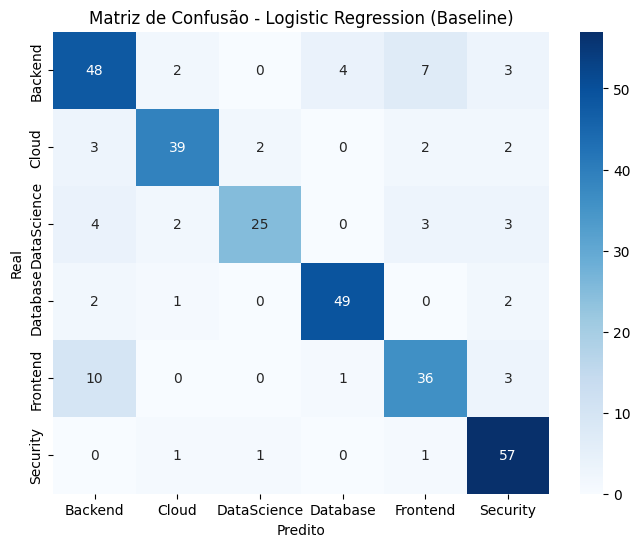

In [14]:
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A confusão está espalhada entre as categorias, sem um padrão dominante. 
* A maior concentração de erros ocorre entre Frontend e Backend (10 casos de Frontend classificados como Backend), sugerindo sobreposição de vocabulário técnico entre essas categorias.
* Security e Cloud, por outro lado, apresentam baixíssima confusão cruzada, confirmando seu bom desempenho.

O modelo baseline de Regressão Logística obteve um desempenho consistente (81% de acurácia, F1 macro 0.81), sem nenhuma categoria com fragilidade evidente. 

Ainda assim, testaremos o modelo com o parâmetro class_weight='balanced', que ajusta o peso das classes durante o treino de forma inversamente proporcional à frequência de cada categoria, para verificar se esse ajuste traz algum ganho adicional em categorias com menos registros, como DataScience.

### Modelagem - Logistic Regression (com class_weight='balanced')

#### Criando Modelo 

In [15]:
# Criando modelo 
modelo_lr_balanced = LogisticRegression(max_iter=1000, 
                                        random_state=42, 
                                        class_weight='balanced')

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [16]:
# Cross-validation
scores_lr_balanced = cross_val_score(
    modelo_lr_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr_balanced.mean():.4f} (+/- {scores_lr_balanced.std():.4f})")

F1 macro: 0.8113 (+/- 0.0153)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0.8113, com desvio padrão de 0.0153 entre os 5 folds. Comparado ao baseline (F1 macro 0.7918, desvio 0.0161), o modelo balanced teve desempenho médio superior e leve redução na variação entre os folds, o que reforça a decisão de avançar com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [17]:
# Treino
modelo_lr_balanced.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Comparação - Avaliação dos Modelos Logistic Regression

In [18]:
# Predição Modelo com balanced
y_pred_lr_balanced = modelo_lr_balanced.predict(X_test_tfidf)

In [19]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_lr_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.72   0.75     0.73   64.00      0.80   0.67     0.73   
Cloud             0.87   0.81     0.84   48.00      0.85   0.85     0.85   
DataScience       0.89   0.68     0.77   37.00      0.71   0.73     0.72   
Database          0.91   0.91     0.91   54.00      0.88   0.91     0.89   
Frontend          0.73   0.72     0.73   50.00      0.74   0.78     0.76   
Security          0.81   0.95     0.88   60.00      0.84   0.90     0.87   
accuracy          0.81   0.81     0.81    0.81      0.81   0.81     0.81   
macro avg         0.82   0.80     0.81  313.00      0.80   0.81     0.80   
weighted avg      0.81   0.81     0.81  313.00      0.81   0.81     0.81   

                      
             support  
Backend        64.00  
Cloud          48.00  
DataScience    37.00  
Database       54.00  
Frontend       50.00  
Security       60.00  
accuracy        0.81  
macro avg     313.00  
weighted avg  313.00

A tabela comparativa mostra que os dois modelos tiveram a mesma acurácia (0.81). No macro avg, o F1-score foi levemente menor no balanced (0.80) em relação ao baseline (0.81), embora o recall médio tenha sido um pouco maior (0.81 contra 0.80) e a precision média menor (0.80 contra 0.82).

Em DataScience, o balanced trouxe um trade-off: o recall subiu de 0.68 para 0.73, mas a precision caiu de 0.89 para 0.71, resultando em um F1-score menor (de 0.77 para 0.72).

Em Backend, aconteceu o oposto: a precision subiu de 0.72 para 0.80, enquanto o recall caiu de 0.75 para 0.67, mantendo o F1-score praticamente igual (0.73 nos dois modelos).

Nas demais categorias, as variações foram pequenas: Cloud (F1 0.84 para 0.85) e Frontend (F1 0.73 para 0.76) melhoraram levemente, enquanto Database (F1 0.91 para 0.89) e Security (F1 0.88 para 0.87) caíram um pouco.

No geral, o balanceamento não trouxe ganho evidente nessa base. 

#### Comparação - Matriz de Confusão

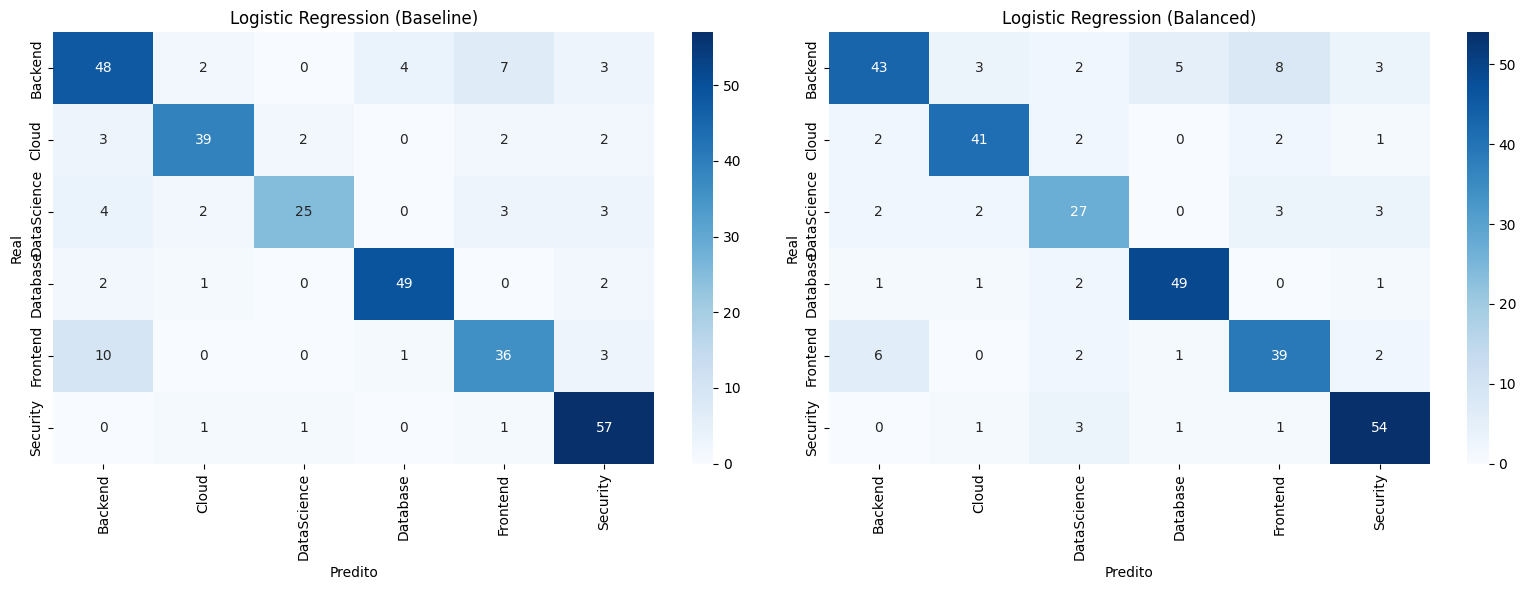

In [20]:
# Comparando as matrizes de confusão 
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_lr_balanced, labels=modelo_lr_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr_balanced.classes_, yticklabels=modelo_lr_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Logistic Regression (Balanced)')

plt.tight_layout()
plt.show()

Comparando as duas matrizes, DataScience teve mais acertos no balanced (27 contra 25 no baseline), e a confusão com Backend caiu de 4 para 2 casos.

Em compensação, Backend teve menos acertos no balanced (43 contra 48 no baseline), recebendo mais confusão vinda de Frontend (8 casos, contra 7 no baseline). A confusão entre DataScience e Backend, por outro lado, diminuiu nos dois sentidos.

Cloud e Security permaneceram com padrão parecido nos dois modelos, com pequenas variações pontuais.

Conclusão - Modelo Logistic Regression

Comparando os dois modelos, o balanceamento não trouxe ganho real nessa base já mais equilibrada após a limpeza. 

Em DataScience, o ganho de recall veio acompanhado de uma queda maior na precision, reduzindo o F1 da categoria. 

Em Backend, o ganho de precision veio acompanhado de uma queda equivalente no recall, mantendo o F1 praticamente igual. 

No resultado geral, essas trocas não se traduziram em melhora. O F1 macro do balanced ficou levemente abaixo do baseline (0.80 contra 0.81). 

Considerando essas informações, o modelo baseline será considerado o modelo final da Regressão Logística.

## Modelo Naive Bayes

In [21]:
# AGUARANDO 

## Modelo SVM 

In [22]:
# AGUARANDO 

## Comparação dos Modelos

AGUARDANDO DESENVOLVIMENTOS DOS DEMAIS MODELOS PARA COMPARAÇÃO 

## Extração de Palavras-Chave

A extração das palavras chave é realizada reaproveitando o mesmo vetor TF-IDF aplicado no treinamento do modelo. É possível extrair as palavras mais relevantes do texto, identificando os termos com maior peso (score TF-IDF) para aquele texto específico. Esses termos podem ser utilizados para facilitar buscas, organização e reutilização do conhecimento dentro da plataforma TechMind.

In [23]:
def extrair_palavras_chave(texto, vectorizer, top_n=5):
    # Transforma o texto em vetor TF-IDF usando o vectorizer já treinado
    tfidf_vector = vectorizer.transform([texto])
    
    # Extrai os pesos TF-IDF do texto (matriz esparsa vira array simples de números)
    scores = tfidf_vector.toarray()[0]

    # Recupera os termos existentes no TF-IDF
    termos = vectorizer.get_feature_names_out()
    
    # Pega os índices dos termos com maior peso, em ordem decrescente
    top_indices = scores.argsort()[-top_n:][::-1]
    
    # Retorna as palavras ordenadas por relevância
    palavras_chave = [termos[i] for i in top_indices if scores[i] > 0]

    # Se quiser ver com o indice
    #palavras_chave = [(termos[i], round(scores[i], 3)) for i in top_indices if scores[i] > 0]
    
    return palavras_chave

In [24]:
# Testando a extração de palavras-chave em alguns exemplos
resultados = []

for i in range(5):
    texto = X_test.iloc[i]
    categoria = y_test.iloc[i]
    palavras_chave = extrair_palavras_chave(texto, vectorizer, top_n=3)
    resultados.append({'categoria': categoria, 'palavras_chave': palavras_chave})

df_palavras_chave = pd.DataFrame(resultados)
df_palavras_chave

,categoria,palavras_chave
0,Backend,"[agent, ai, event]"
1,Frontend,"[score, style, option]"
2,Cloud,"[container, azure, ngrok]"
3,Backend,"[ocr, winner, llm]"
4,Database,"[ollama, ai, erd]"


Testando a função de extração de palavras-chave em uma amostra do conjunto de teste, alguns resultados foram coerentes com a categoria real, como Cloud (container, azure, ngrok) e Database (ollama, ai, erd).

Ainda assim, é possível notar sobreposição de vocabulário entre categorias. O termo "ai" aparece tanto em exemplos de Backend quanto de Database, refletindo o quanto certas tecnologias (como IA e LLMs) permeiam múltiplas áreas técnicas. Isso é uma limitação esperada do TF-IDF, que identifica termos estatisticamente relevantes para o texto, mas não necessariamente exclusivos de uma única categoria.

## Estrutura do Retorno do Modelo

O objetivo é preparar e simular a saída que será consumida pela API da aplicação, reunindo:

- Categoria prevista pelo modelo de classificação;
- Probabilidade associada à previsão;
- Palavras-chave extraídas do conteúdo analisado.

Esse teste considera os dados em memória

In [25]:
# Função simulação 
def analisar_conteudo(texto):
    
    # Transformar texto para o formato do modelo
    texto_tfidf = vectorizer.transform([texto])
    
    # Categoria prevista
    categoria = modelo_lr.predict(texto_tfidf)[0]
    
    # Probabilidade da previsão
    probabilidades = modelo_lr.predict_proba(texto_tfidf)[0]
    probabilidade = float(probabilidades.max())
    
    # Palavras-chave
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": round(probabilidade, 2),
        "informacoes_adicionais": palavras_chave
    }

In [26]:
# definindo texto teste
texto_teste = df_model.loc[0, 'texto']

In [27]:
# Simulando o retorno
resultado = analisar_conteudo(texto_teste)
resultado

{'categoria': 'Security',
 'probabilidade': 0.67,
 'informacoes_adicionais': ['ssh', 'mfa', 'google']}

### Análise da Probabilidade de Classificação

In [28]:
# Verificando todas as probabilidades do texto teste
probabilidades = modelo_lr.predict_proba(
    vectorizer.transform([texto_teste])
)[0]

df_prob = pd.DataFrame({
    'Categoria': modelo_lr.classes_,
    'Probabilidade': probabilidades
})

df_prob['Probabilidade'] = df_prob['Probabilidade'].round(4)

df_prob = df_prob.sort_values(
    by='Probabilidade',
    ascending=False
)

df_prob

,Categoria,Probabilidade
5,Security,0.6692
1,Cloud,0.0823
0,Backend,0.0820
3,Database,0.0677
4,Frontend,0.0628
2,DataScience,0.0359


O modelo retorna a distribuição de probabilidades entre todas as classes possíveis. Neste exemplo, a categoria Security apresentou a maior probabilidade de classificação (66,92%), enquanto as demais categorias apresentaram valores inferiores. Essa informação permite avaliar o nível de confiança associado à previsão realizada pelo modelo.

A probabilidade será utilizada como uma informação adicional no retorno da API, permitindo que aplicações consumidoras tenham visibilidade sobre o grau de confiança da classificação.

## Serialização do Modelo

A serialização permite salvar o modelo treinado e o vetor TF-IDF em arquivo persistente, possibilitando que a aplicação Back-End carregue esses componentes sem a necessidade de realizar novamente o treinamento.

Serão armazenados:

- Modelo de classificação (`modelo_lr`);
- Vetorizador TF-IDF (`vectorizer`).

O arquivo .pkl armazendo será utilizado posteriormente pela API da aplicação Techmind para realizar novas classificações de conteúdos técnicos, juntamente com a extração das palavras-chave e geração das informações de retorno.

In [29]:
# Gerando arquivo .pkl
artefatos_modelo = {
    "modelo": modelo_lr,
    "vectorizer": vectorizer
}

joblib.dump(
    artefatos_modelo,
    '../modelo/modelo_techmind.pkl'
)

['../modelo/modelo_techmind.pkl']

## Exemplos de Uso (JSON)

Nesta etapa será simulada a utilização do modelo em um cenário próximo ao funcionamento da API.

Serão enviados exemplos de conteúdos técnicos como entrada, representando requisições realizadas por usuários. O modelo realizará a classificação do conteúdo, calculará a probabilidade da previsão e retornará as palavras-chave identificadas.

A saída será estruturada em formato JSON, seguindo o padrão esperado para integração com a aplicação Backend.

In [30]:
# Simula o consumo o arquivo .pkl
artefatos = joblib.load('../modelo/modelo_techmind.pkl')

modelo = artefatos["modelo"]
vectorizer = artefatos["vectorizer"]

In [31]:
# Confirma que os artefatos foram carregados corretamente a partir do .pkl
type(modelo), type(vectorizer)

(sklearn.linear_model._logistic.LogisticRegression,
 sklearn.feature_extraction.text.TfidfVectorizer)

In [32]:
# Texto Teste
textos_teste = (
    df_model['texto']
    .sample(3, random_state=42)
    .tolist()
)

textos_teste

['building dashboard write sql query create report essential organize datum way accurately represent real - world entity capture interaction . process know datum modeling . data model picture - storey building let database building . lets label floor - schema . floor unique identity pair corresponding floor number floor schema- floor schema apartment label table pair unique unit number table- table- forth . apartment unit table different characteristic define size number room . instance schema- studio unit schema- - bedroom unit different floor area . similarly relate table database host schema . organizational blueprint refer data model . schema structure schema typically take structure dictate relationship table inside . star schema . suggest take shape star . setup central table call fact table relationship table call dimension table . fact table explain _ happen _ dimension table give context _ _ . snowflake schema . schema take shape snowflake . dimension table relate subcategorie

In [33]:
def analisar_conteudo_api(texto, modelo, vectorizer):
    
    texto_tfidf = vectorizer.transform([texto])
    
    categoria = modelo.predict(texto_tfidf)[0]
    
    probabilidade = modelo.predict_proba(texto_tfidf).max()
    
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": float(probabilidade),
        "informacoes_adicionais": palavras_chave
    }

In [34]:
# Simulando resultado
resultados_json = []

for texto in textos_teste:
    
    resultado = analisar_conteudo_api(
        texto,
        modelo,
        vectorizer
    )
    
    resultados_json.append(resultado)


print(json.dumps(resultados_json, indent=4, ensure_ascii=False))

[
    {
        "categoria": "Database",
        "probabilidade": 0.7555978076766706,
        "informacoes_adicionais": [
            "table",
            "relationship",
            "join"
        ]
    },
    {
        "categoria": "Security",
        "probabilidade": 0.4818252576368414,
        "informacoes_adicionais": [
            "address",
            "ipv",
            "privacy"
        ]
    },
    {
        "categoria": "Frontend",
        "probabilidade": 0.2900335596907144,
        "informacoes_adicionais": [
            "gate",
            "fan",
            "app"
        ]
    }
]


Os resultados demonstram que o modelo conseguiu gerar as previsões utilizando os artefatos carregados a partir do arquivo `.pkl`, mantendo a integração entre o modelo de classificação e o vetor TF-IDF utilizado no treinamento. 

As probabilidades retornadas indicam o nível de confiança da classificação para cada conteúdo analisado, enquanto as palavras-chave destacam os termos mais relevantes identificados na representação vetorial do texto.

Nos três exemplos testados, o modelo classificou corretamente os temas centrais dos textos: Database (75,6% de confiança, com palavras-chave table, relationship, join), Security (48,2%, com address, ipv, privacy) e Frontend (29%, com gate, fan, app). O terceiro caso, com probabilidade mais baixa, mostra um texto de classificação mais incerta, situação esperada em conteúdos que abordam temas com vocabulário menos exclusivo de uma única categoria.

O retorno já está no formato JSON esperado pela API, pronto para ser consumido pelo backend.

## Conclusões

In [35]:
# PENDENTE DEMAIS MODELOS 